In [2]:
print("Hello Sid")

Hello Sid


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
os.getcwd()

'C:\\Users\\15130\\Downloads\\Project - Parcl Co Limited\\Notebooks'

In [5]:
os.listdir()

['.ipynb_checkpoints', '01_data_audit_eda.ipynb']

In [6]:
os.listdir("..")

['Data-processed',
 'Data-raw',
 'Machine learning based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence.pdf',
 'Notebooks',
 'Output-charts',
 'Output-Models',
 'Project Understanding.docx',
 'Report',
 'Roadmap.docx',
 'Scripts',
 'SQL to Python mental mapping.docx',
 'Streamlit-App']

In [7]:
os.listdir("Data-raw")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Data-raw'

In [8]:
os.listdir()

['.ipynb_checkpoints', '01_data_audit_eda.ipynb']

In [9]:
os.listdir("..")

['Data-processed',
 'Data-raw',
 'Machine learning based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence.pdf',
 'Notebooks',
 'Output-charts',
 'Output-Models',
 'Project Understanding.docx',
 'Report',
 'Roadmap.docx',
 'Scripts',
 'SQL to Python mental mapping.docx',
 'Streamlit-App']

In [10]:
os.listdir("../Data-raw")

['clients.csv', 'properties.csv']

In [11]:
df = pd.read_csv("../Data-raw/clients.csv")

NameError: name 'pd' is not defined

In [12]:
import pandas as pd 
df = pd.read_csv("../Data-raw/clients.csv")

In [13]:
df.head

<bound method NDFrame.head of      client_id client_type first_name   last_name date_of_birth gender  \
0        C0001  Individual     Kareem         Liu    05-11-1968      F   
1        C0002  Individual    Trystan     Oconnor    11/26/1962      M   
2        C0003  Individual       Kale         Gay    04-07-1959      M   
3        C0004  Individual    Russell       Gross    11/25/1959      M   
4        C0005     Company    Marleez          Co     2/28/1976      M   
...        ...         ...        ...         ...           ...    ...   
1995     C1996  Individual   Samantha      Brooks     6/20/1992      F   
1996     C1997  Individual    Matthew         Cox     9/27/1942      M   
1997     C1998  Individual       Mark   Patterson     9/13/1963      M   
1998     C1999  Individual   Lawrence  Montgomery     6/15/1944      M   
1999     C2000  Individual     Amanda       James     3/24/1996      F   

     country      region acquisition_purpose  satisfaction_score loan_applied  \


In [14]:
df.shape

(2000, 12)

In [15]:
df.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [17]:
df.isna().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["client_id"].duplicated().sum()

np.int64(0)

In [20]:
df.head(10)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website
5,C0006,Individual,Yurem,Wright,03-06-1957,M,USA,California,Home,3,Yes,Website
6,C0007,Individual,Xavier,Faulkner,5/24/1947,M,Canada,Quebec,Investment,5,No,Website
7,C0008,Individual,Kayden,Olsen,10/17/1969,F,USA,California,Home,5,No,Website
8,C0009,Individual,Joaquin,Mullins,10-05-1975,M,USA,California,Investment,5,No,Agency
9,C0010,Individual,Nicolas,Navarro,6/17/1966,M,USA,Oregon,Investment,3,No,Agency


In [21]:
df_clean = df.copy()

In [22]:
categorical_cols = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]
for col in categorical_cols:
    print("\n---",col,"---")
    print(df_clean[col].value_counts())


--- client_type ---
client_type
Individual    1897
Company        103
Name: count, dtype: int64

--- gender ---
gender
M    1012
F     988
Name: count, dtype: int64

--- country ---
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

--- region ---
region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Ohio                       24
Northern Ireland           24
British Columbia           20
Wales                      17
Brittany  

In [23]:
text_cols = df_clean.select_dtypes(include="object").columns

for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

In [24]:
df.head(500)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website
...,...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,Individual,Billy,Reyes,01-04-1990,M,USA,California,Home,4,No,Agency
496,C0497,Individual,Emma,Stewart,02-02-1985,F,USA,Arizona,Investment,4,Yes,Website
497,C0498,Individual,Nancy,Collins,11/21/1948,F,Canada,Alberta,Home,2,Yes,Website
498,C0499,Individual,Lisa,Patterson,02-10-1946,F,USA,Colorado,Home,3,Yes,Agency


In [25]:
df_clean["dob_parsed"] = df_clean["date_of_birth"].apply(
    lambda x: pd.to_datetime(x, errors="coerce", dayfirst=False)
)

In [26]:
df_clean["dob_parsed"].isna().sum()

np.int64(0)

In [27]:
df_clean[["date_of_birth","dob_parsed"]].head(20)

,date_of_birth,dob_parsed
0,05-11-1968,1968-05-11
1,11/26/1962,1962-11-26
2,04-07-1959,1959-04-07
3,11/25/1959,1959-11-25
4,2/28/1976,1976-02-28
5,03-06-1957,1957-03-06
6,5/24/1947,1947-05-24
7,10/17/1969,1969-10-17
8,10-05-1975,1975-10-05
9,6/17/1966,1966-06-17


In [28]:
today = pd.Timestamp.today()
df_clean["age"] = ((today - df_clean["dob_parsed"]).dt.days / 365.25).round()

In [29]:
df_clean[["date_of_birth", "dob_parsed", "age"]].head(10)

,date_of_birth,dob_parsed,age
0,05-11-1968,1968-05-11,58.0
1,11/26/1962,1962-11-26,63.0
2,04-07-1959,1959-04-07,67.0
3,11/25/1959,1959-11-25,66.0
4,2/28/1976,1976-02-28,50.0
5,03-06-1957,1957-03-06,69.0
6,5/24/1947,1947-05-24,79.0
7,10/17/1969,1969-10-17,56.0
8,10-05-1975,1975-10-05,50.0
9,6/17/1966,1966-06-17,60.0


In [30]:
df_clean["age"].describe()

count    2000.000000
mean       55.857500
std        17.362371
min        25.000000
25%        41.000000
50%        56.000000
75%        70.000000
max        95.000000
Name: age, dtype: float64

In [31]:
df_clean["age"].describe()

count    2000.000000
mean       55.857500
std        17.362371
min        25.000000
25%        41.000000
50%        56.000000
75%        70.000000
max        95.000000
Name: age, dtype: float64

In [32]:
df_clean["age"].sort_values().head(10)

1438    25.0
565     25.0
730     25.0
626     25.0
842     25.0
1574    25.0
1624    26.0
1184    26.0
1191    26.0
1200    26.0
Name: age, dtype: float64

In [33]:
df_clean["age"].sort_values(ascending = False).head(10)

43     95.0
133    94.0
108    93.0
56     93.0
87     90.0
24     89.0
20     88.0
82     87.0
134    87.0
137    87.0
Name: age, dtype: float64

In [34]:
df_clean["age"] = df_clean["age"].astype(int)

In [35]:
df_clean.to_csv("../Data-processed/clients_cleaned.csv", index=False)

In [36]:
os.listdir()


['.ipynb_checkpoints', '01_data_audit_eda.ipynb']

In [37]:
os.listdir(..)

SyntaxError: invalid syntax (4069799356.py, line 1)

In [38]:
os.listdir("..")

['Data-processed',
 'Data-raw',
 'Machine learning based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence.pdf',
 'Notebooks',
 'Output-charts',
 'Output-Models',
 'Project Understanding.docx',
 'Report',
 'Roadmap.docx',
 'Scripts',
 'SQL to Python mental mapping.docx',
 'Streamlit-App']

In [39]:
os.listdir("../Data-processed")

['clients_cleaned.csv']

In [40]:
df_clean["client_type"].value_counts()

client_type
Individual    1897
Company        103
Name: count, dtype: int64

In [41]:
df_clean["acquisition_purpose"].value_counts()

acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

In [42]:
df_clean["loan_applied"].value_counts()

loan_applied
No     1264
Yes     736
Name: count, dtype: int64

In [43]:
df_clean["referral_channel"].value_counts()

referral_channel
Website    1103
Agency      705
Client      192
Name: count, dtype: int64

In [44]:
df_clean["gender"].value_counts()

gender
M    1012
F     988
Name: count, dtype: int64

In [45]:
df_clean["country"].value_counts().head(10)

country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

In [46]:
df_clean["region"].value_counts().head(10)

region
California    633
Nevada        143
Colorado      118
Arizona       108
Oregon         96
Utah           87
Washington     73
Virginia       65
Texas          56
Florida        50
Name: count, dtype: int64

In [47]:
df_clean["satisfaction_score"].describe()

count    2000.000000
mean        3.029000
std         1.413562
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: satisfaction_score, dtype: float64

In [48]:
df_clean["age"].describe()

count    2000.000000
mean       55.857500
std        17.362371
min        25.000000
25%        41.000000
50%        56.000000
75%        70.000000
max        95.000000
Name: age, dtype: float64

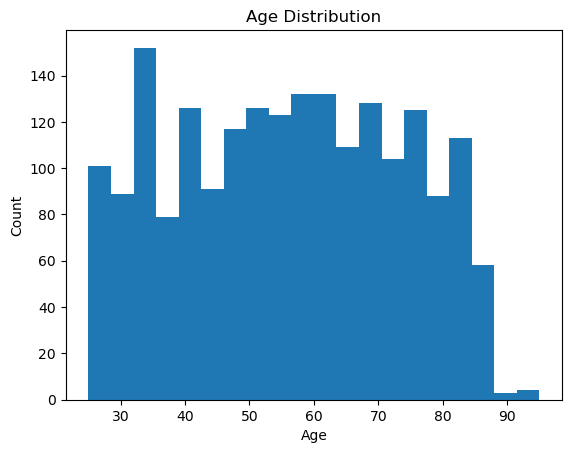

In [49]:
df_clean["age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

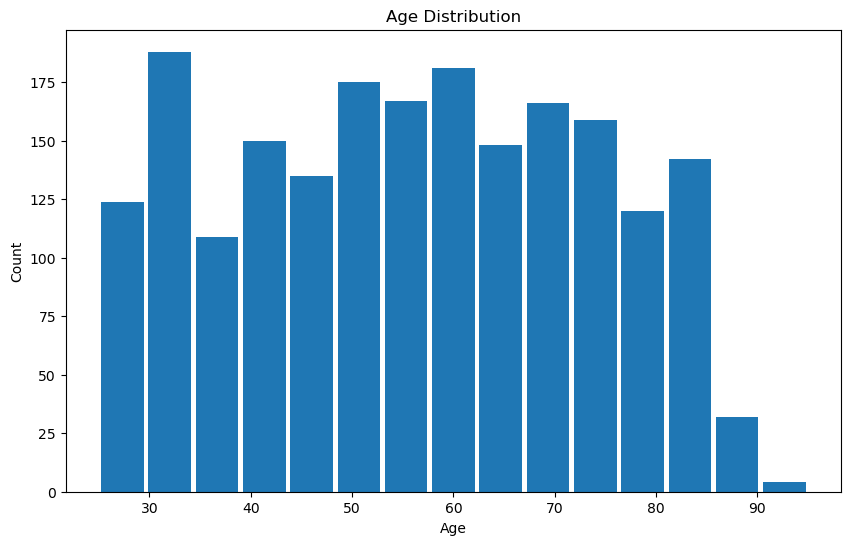

In [50]:
plt.figure(figsize=(10, 6))
df_clean["age"].plot(kind="hist", bins=15, rwidth=0.9)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

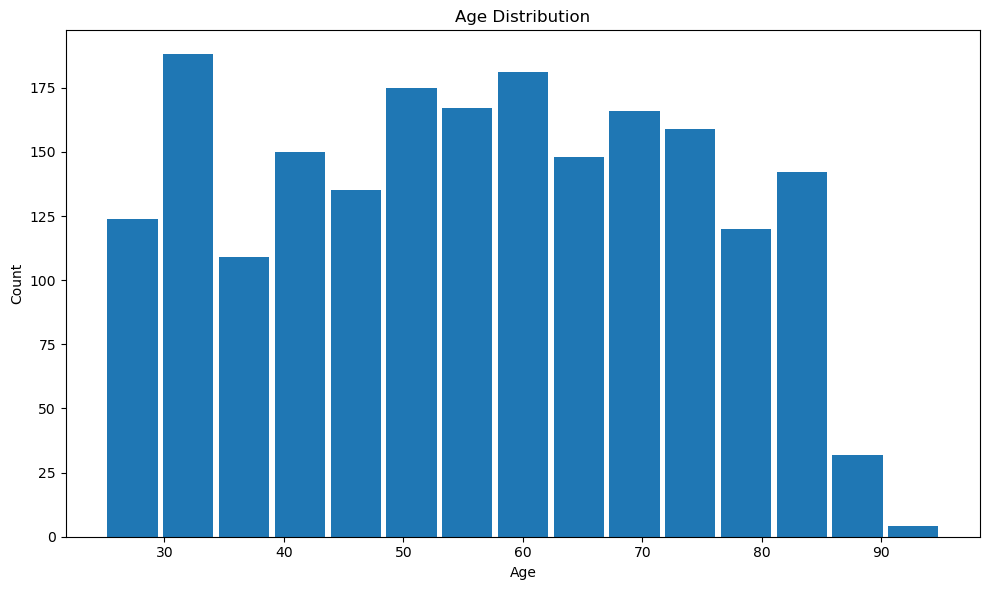

In [51]:
plt.figure(figsize=(10, 6))
df_clean["age"].plot(kind="hist", bins=15, rwidth=0.9)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../Output-charts/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

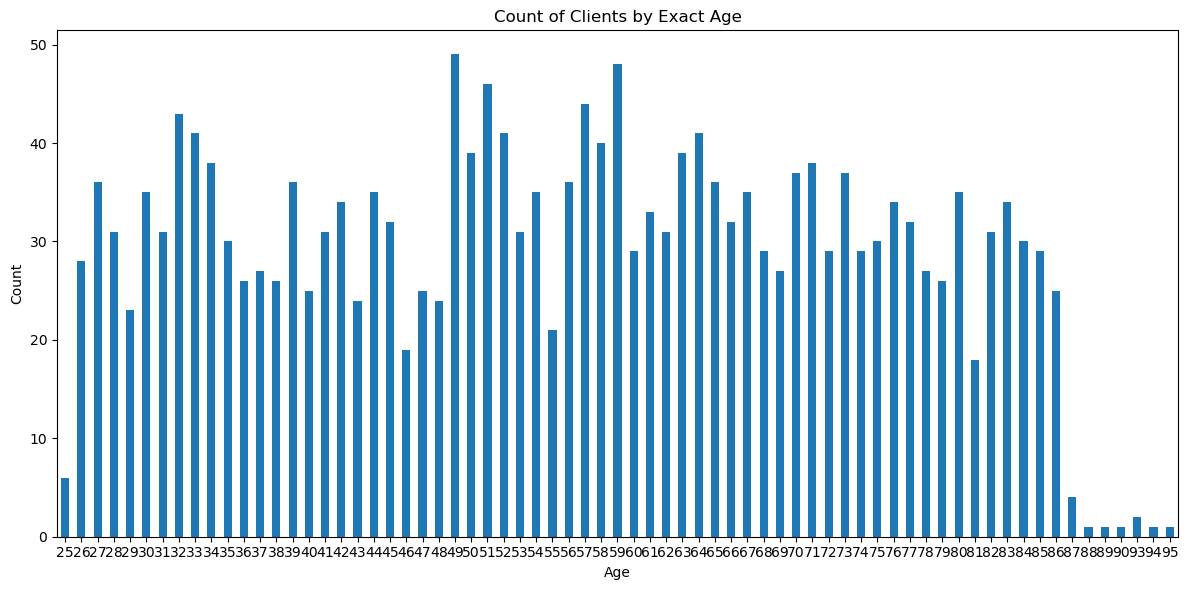

In [52]:
plt.figure(figsize=(12, 6))
df_clean["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Count of Clients by Exact Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

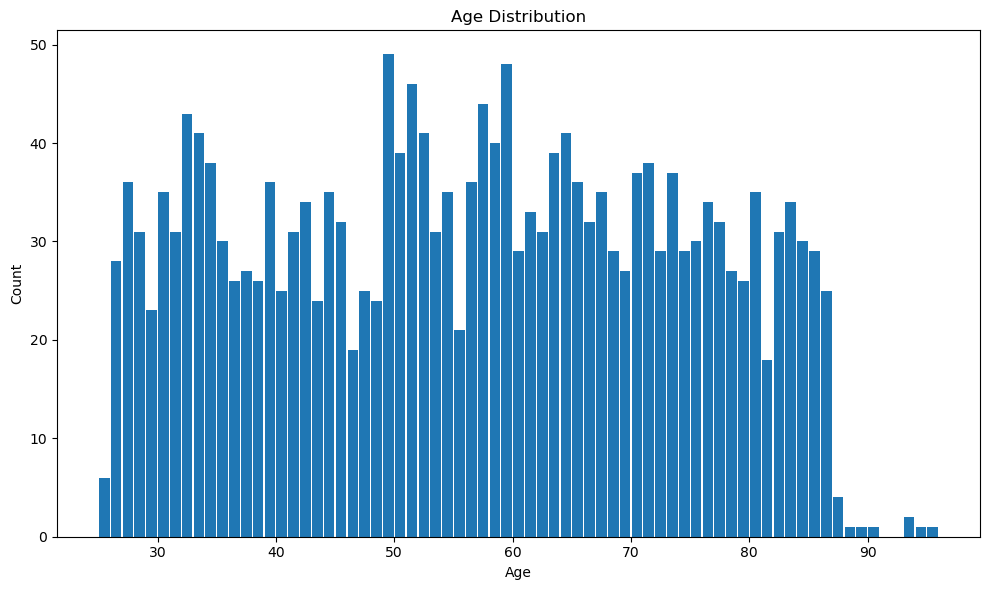

In [53]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["age"], bins=range(df_clean["age"].min(), df_clean["age"].max() + 2), rwidth=0.9)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

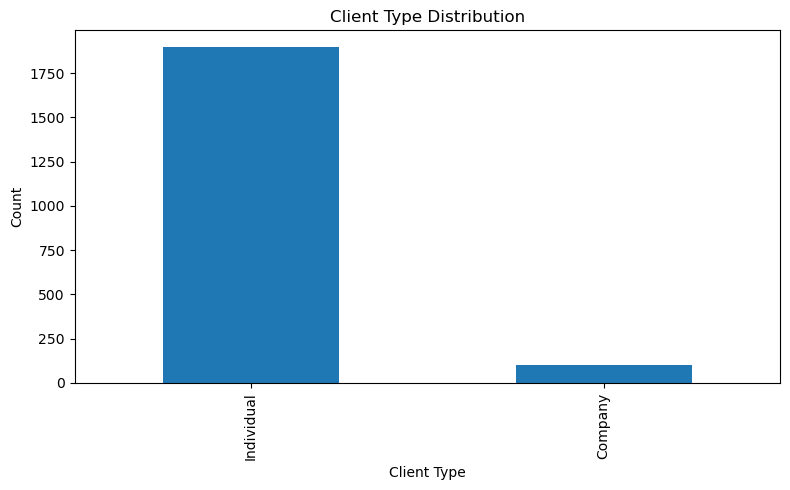

In [54]:
plt.figure(figsize=(8, 5))
df_clean["client_type"].value_counts().plot(kind="bar")
plt.title("Client Type Distribution")
plt.xlabel("Client Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

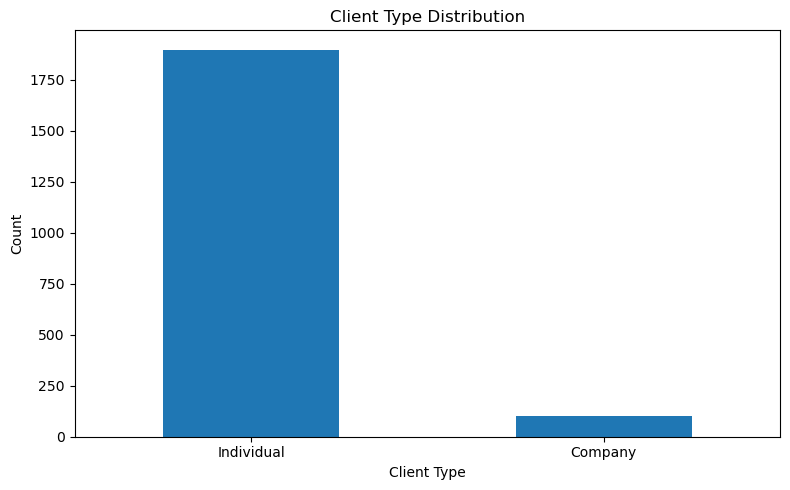

In [55]:
plt.figure(figsize=(8, 5))
df_clean["client_type"].value_counts().plot(kind="bar")
plt.title("Client Type Distribution")
plt.xlabel("Client Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

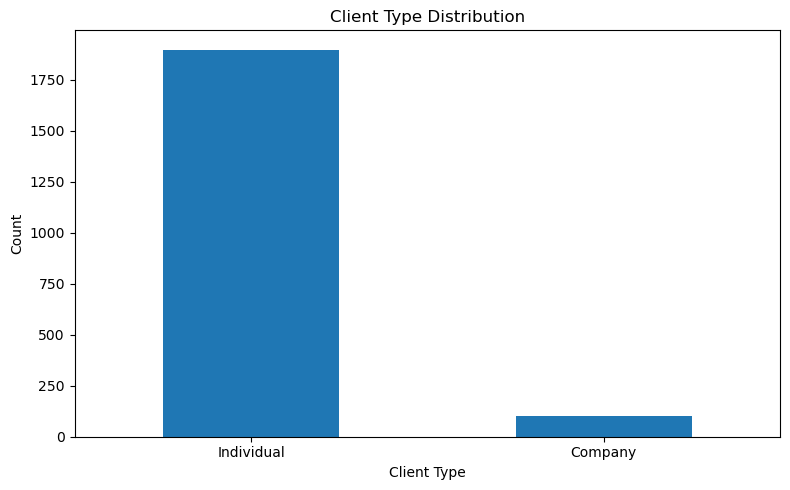

In [56]:
plt.figure(figsize=(8, 5))
df_clean["client_type"].value_counts().plot(kind="bar")
plt.title("Client Type Distribution")
plt.xlabel("Client Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/client_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

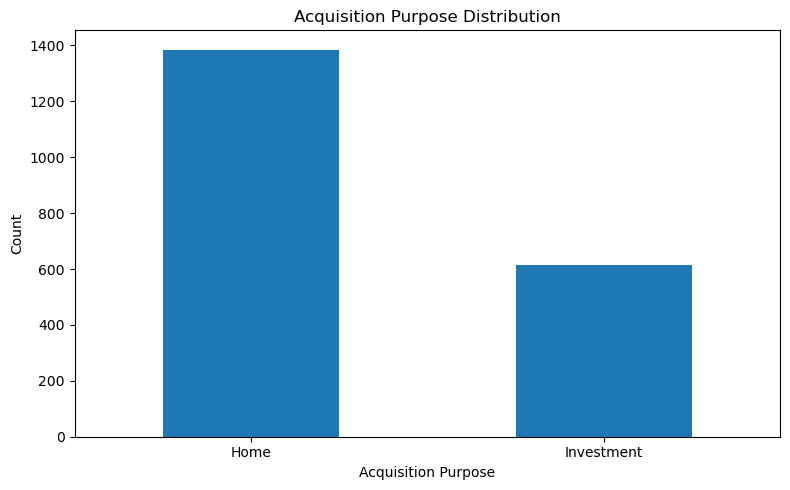

In [57]:
plt.figure(figsize=(8, 5))
df_clean["acquisition_purpose"].value_counts().plot(kind="bar")
plt.title("Acquisition Purpose Distribution")
plt.xlabel("Acquisition Purpose")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

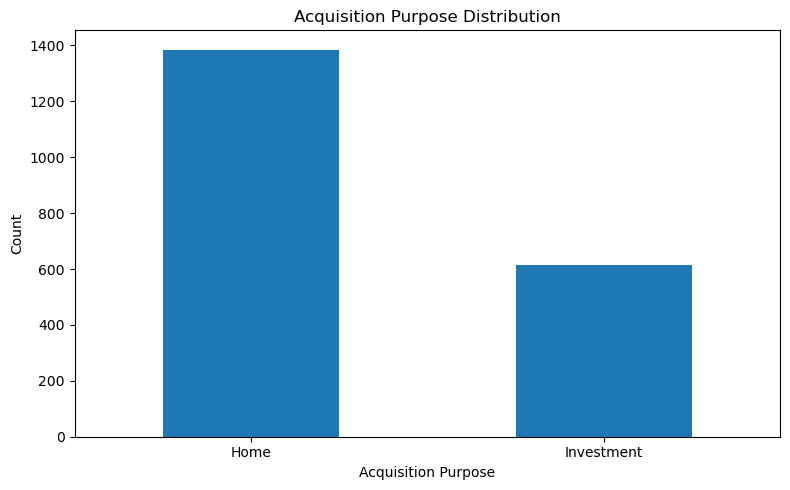

In [58]:
plt.figure(figsize=(8, 5))
df_clean["acquisition_purpose"].value_counts().plot(kind="bar")
plt.title("Acquisition Purpose Distribution")
plt.xlabel("Acquisition Purpose")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

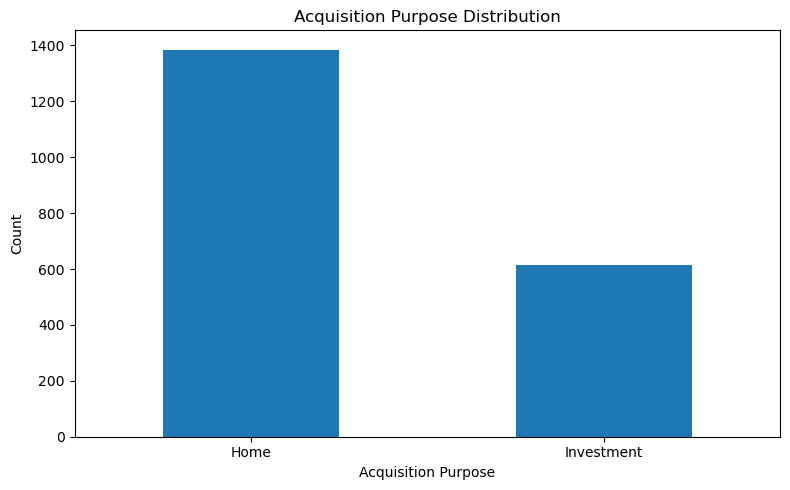

In [59]:
plt.figure(figsize=(8, 5))
df_clean["acquisition_purpose"].value_counts().plot(kind="bar")
plt.title("Acquisition Purpose Distribution")
plt.xlabel("Acquisition Purpose")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/client_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

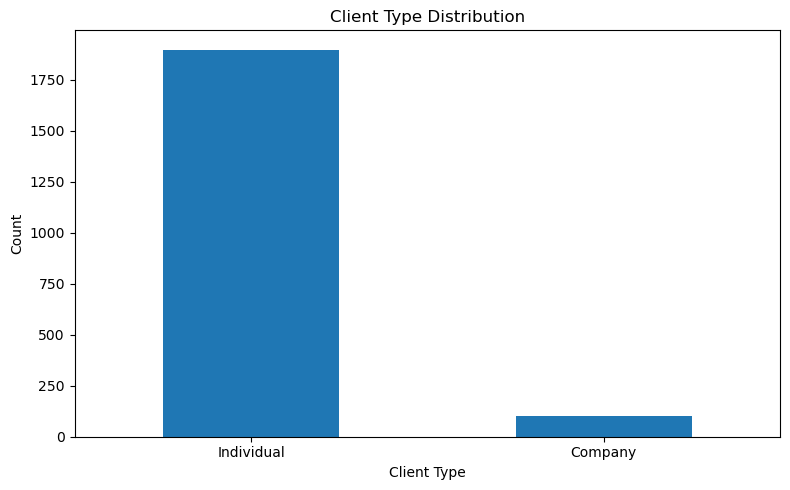

In [60]:
plt.figure(figsize=(8, 5))
df_clean["client_type"].value_counts().plot(kind="bar")
plt.title("Client Type Distribution")
plt.xlabel("Client Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/client_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

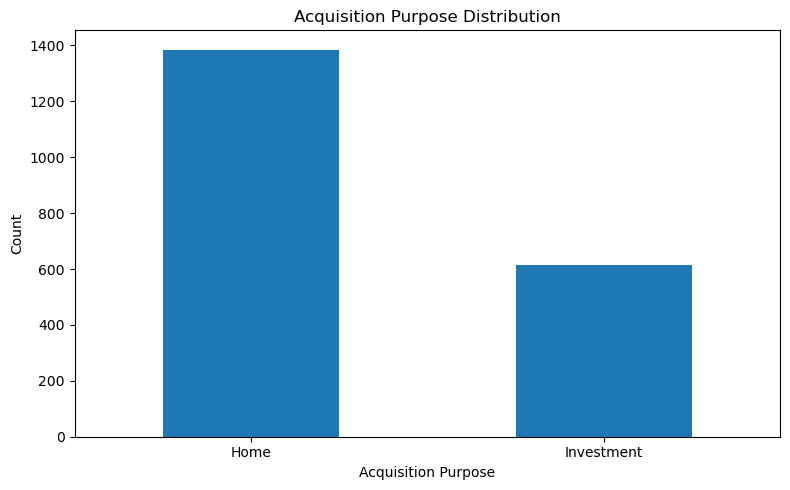

In [61]:
plt.figure(figsize=(8, 5))
df_clean["acquisition_purpose"].value_counts().plot(kind="bar")
plt.title("Acquisition Purpose Distribution")
plt.xlabel("Acquisition Purpose")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/acquisition_purpose_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

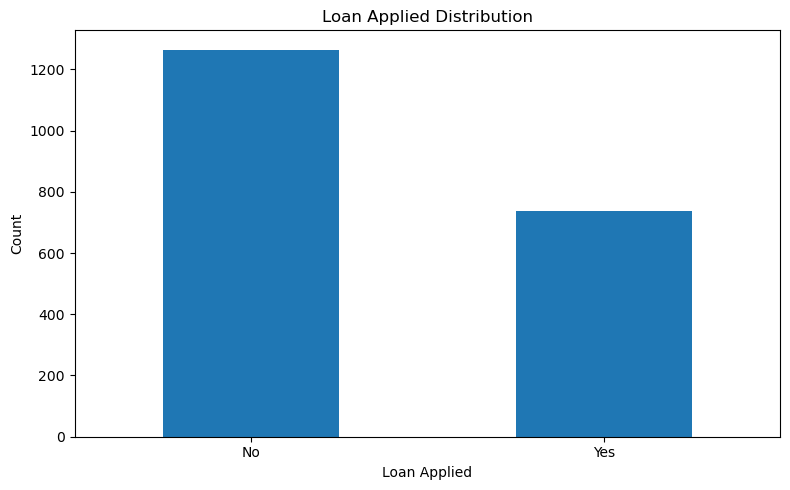

In [62]:
plt.figure(figsize=(8, 5))
df_clean["loan_applied"].value_counts().plot(kind="bar")
plt.title("Loan Applied Distribution")
plt.xlabel("Loan Applied")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/loan_applied_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

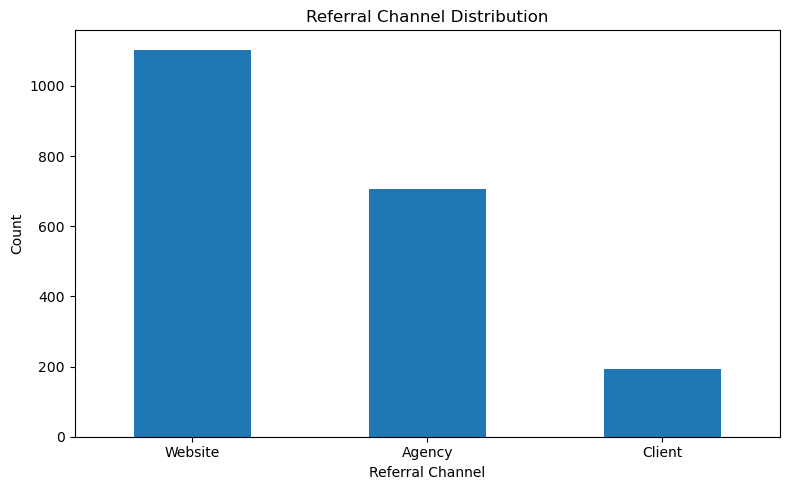

In [63]:
plt.figure(figsize=(8, 5))
df_clean["referral_channel"].value_counts().plot(kind="bar")
plt.title("Referral Channel Distribution")
plt.xlabel("Referral Channel")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/referral_channel_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
pd.crosstab(df_clean["loan_applied"], df_clean["acquisition_purpose"])

acquisition_purpose,Home,Investment
loan_applied,,
No,883,381
Yes,502,234


In [65]:
pd.crosstab(
    df_clean["loan_applied"],
    df_clean["acquisition_purpose"],
    normalize="index"
) * 100

acquisition_purpose,Home,Investment
loan_applied,,
No,69.857595,30.142405
Yes,68.206522,31.793478


In [66]:
pd.crosstab(
    df_clean["loan_applied"],
    df_clean["acquisition_purpose"],
    normalize="index"
).round(2) * 100

acquisition_purpose,Home,Investment
loan_applied,,
No,70.0,30.0
Yes,68.0,32.0


In [67]:
pd.crosstab(df_clean["client_type"], df_clean["acquisition_purpose"])

acquisition_purpose,Home,Investment
client_type,,
Company,67,36
Individual,1318,579


In [68]:
(
    pd.crosstab(
        df_clean["client_type"],
        df_clean["acquisition_purpose"],
        normalize="index"
    ) * 100
).round(2)

acquisition_purpose,Home,Investment
client_type,,
Company,65.05,34.95
Individual,69.48,30.52


In [69]:
df_clean.groupby("acquisition_purpose")["age"].mean()

acquisition_purpose
Home          56.218051
Investment    55.045528
Name: age, dtype: float64

In [70]:
df_clean.groupby("acquisition_purpose")["satisfaction_score"].mean()

acquisition_purpose
Home          3.024549
Investment    3.039024
Name: satisfaction_score, dtype: float64

In [71]:
df_clean.groupby("client_type")["age"].mean()

client_type
Company       47.844660
Individual    56.292567
Name: age, dtype: float64

In [72]:
df_clean.groupby("client_type")["satisfaction_score"].mean()

client_type
Company       3.067961
Individual    3.026885
Name: satisfaction_score, dtype: float64

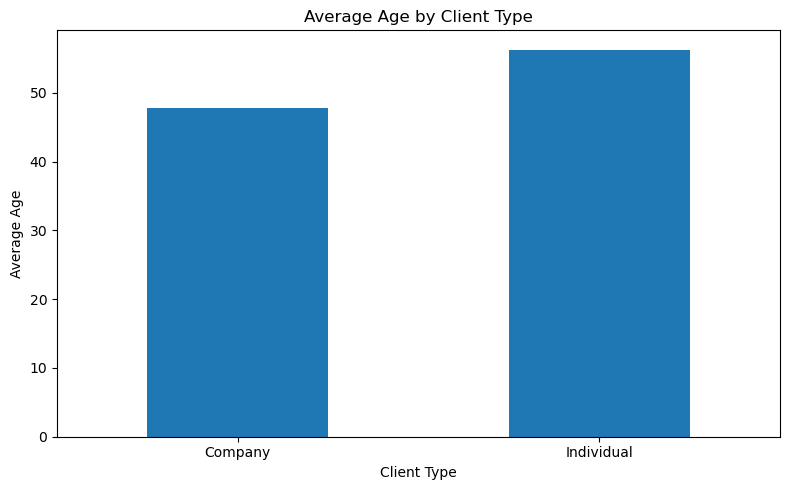

In [73]:
plt.figure(figsize=(8, 5))
df_clean.groupby("client_type")["age"].mean().plot(kind="bar")
plt.title("Average Age by Client Type")
plt.xlabel("Client Type")
plt.ylabel("Average Age")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/average_age_by_client_type.png", dpi=300, bbox_inches="tight")
plt.show()

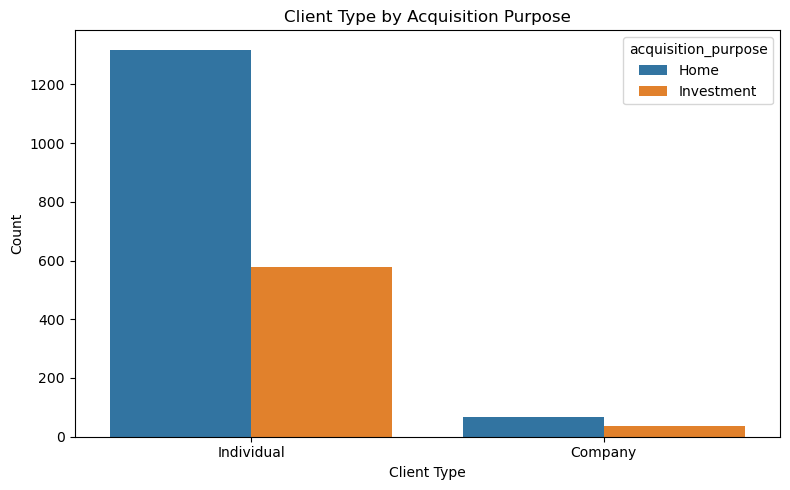

In [74]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="client_type", hue="acquisition_purpose")
plt.title("Client Type by Acquisition Purpose")
plt.xlabel("Client Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/client_type_by_acquisition_purpose.png", dpi=300, bbox_inches="tight")
plt.show()

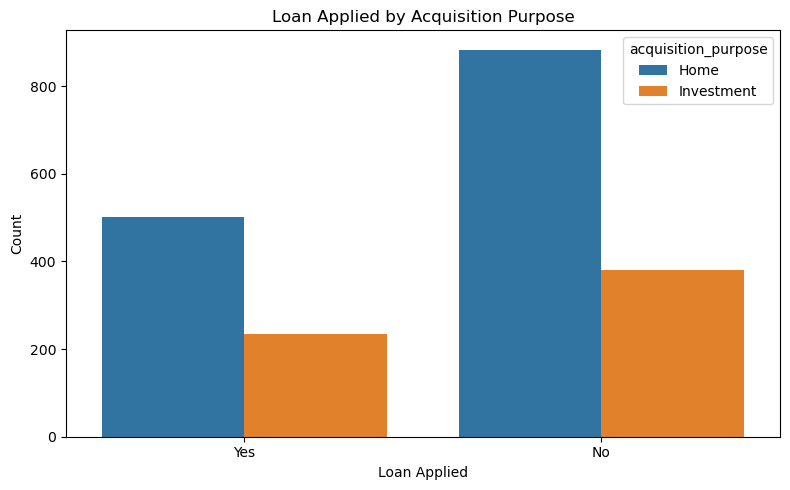

In [75]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="loan_applied", hue="acquisition_purpose")
plt.title("Loan Applied by Acquisition Purpose")
plt.xlabel("Loan Applied")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Output-charts/loan_applied_by_acquisition_purpose.png", dpi=300, bbox_inches="tight")
plt.show()

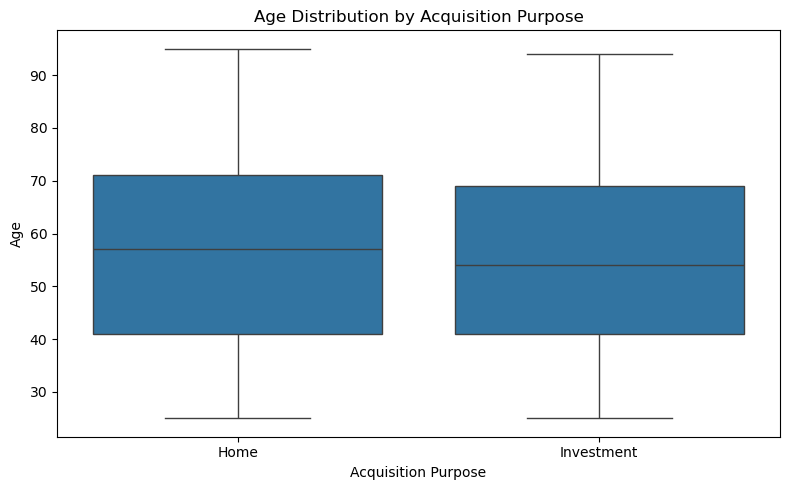

In [76]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="acquisition_purpose", y="age")
plt.title("Age Distribution by Acquisition Purpose")
plt.xlabel("Acquisition Purpose")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig("../Output-charts/age_by_acquisition_purpose_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

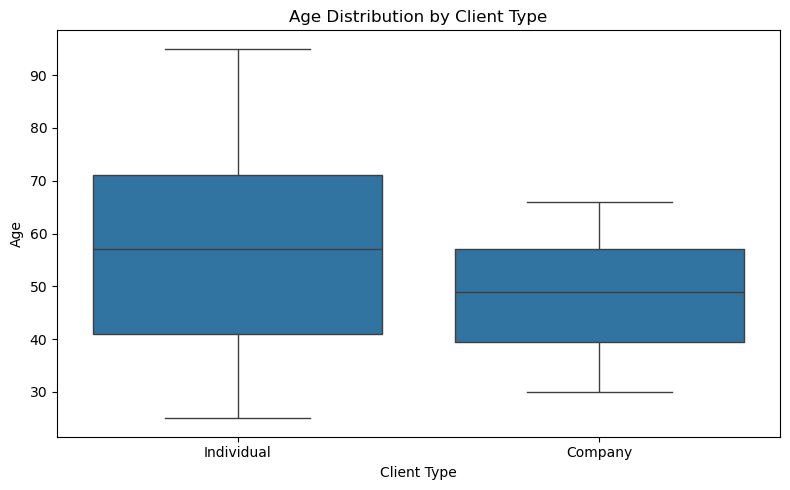

In [77]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="client_type", y="age")
plt.title("Age Distribution by Client Type")
plt.xlabel("Client Type")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig("../Output-charts/age_by_client_type_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
properties = pd.read_csv("../Data-raw/properties.csv")

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
properties = pd.read_csv("../Data-raw/properties.csv")

In [4]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [5]:
properties.shape

(10000, 9)

In [6]:
properties.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='object')

In [7]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB


In [8]:
properties.duplicated().sum()

np.int64(0)

In [9]:
properties.isna().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [10]:
properties["client_ref"].nunique()

2000

In [11]:
properties["client_ref"].isin(df_clean["client_id"]).sum()

NameError: name 'df_clean' is not defined

In [12]:
df_clean = pd.read_csv("../Data-processed/clients_cleaned.csv)

SyntaxError: unterminated string literal (detected at line 1) (1523875115.py, line 1)

In [13]:
os.listdir("../Data-processed")

NameError: name 'os' is not defined

In [14]:
import os
os.getcwd()

'C:\\Users\\15130\\Downloads\\Project - Parcl Co Limited\\Notebooks'

In [15]:
os.listdir("../Data-processed")

['clients_cleaned.csv']

In [16]:
df_clean = pd.read_csv("../Data-processed/clients_cleaned.csv)

SyntaxError: unterminated string literal (detected at line 1) (1523875115.py, line 1)

In [17]:
df_clean = pd.read_csv("../Data-processed/clients_cleaned.csv")

In [18]:
properties["client_ref"].isin(df_clean["client_id"]).sum()

np.int64(7305)

In [19]:
properties.isna().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [20]:
properties["client_ref"].nunique()

2000

In [21]:
properties["client_ref"].isin(df_clean["client_id"]).sum()

np.int64(7305)

In [22]:
properties["client_ref"].value_counts().head(10)

client_ref
C0005    13
C0007    11
C0026    10
C0102     9
C0050     9
C0161     9
C0186     8
C0182     8
C0143     8
C0173     8
Name: count, dtype: int64

In [23]:
properties["listing_status"].value_counts()

listing_status
Sold         7305
Available    2695
Name: count, dtype: int64

In [24]:
properties["unit_category"].value_counts()

unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64

In [25]:
properties["sale_price"].head(10)

0    $300,385.62
1    $208,930.81
2    $218,585.92
3    $246,172.68
4    $212,265.67
5    $275,394.25
6    $310,223.29
7    $356,506.37
8    $212,520.83
9    $407,214.29
Name: sale_price, dtype: object

In [26]:
properties_clean = properties.copy()

In [27]:
properties_clean.to_csv("../Data-processed/properties_cleaned.csv", index = False)

In [28]:
properties_clean["transaction_date_parsed"] = pd.to_datetime(
    properties_clean["transaction_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [29]:
properties_clean["transaction_date_parsed"].isna().sum()

np.int64(0)

In [30]:
properties_clean["sale_price_num"] = (
    properties_clean["sale_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [31]:
properties_clean[["sale_price", "sale_price_num"]].head(10)

,sale_price,sale_price_num
0,"$300,385.62",300385.62
1,"$208,930.81",208930.81
2,"$218,585.92",218585.92
3,"$246,172.68",246172.68
4,"$212,265.67",212265.67
5,"$275,394.25",275394.25
6,"$310,223.29",310223.29
7,"$356,506.37",356506.37
8,"$212,520.83",212520.83
9,"$407,214.29",407214.29


In [32]:
properties_sold = properties_clean[
    (properties_clean["listing_status"] == "Sold") &
    (properties_clean["client_ref"].notna())
].copy()

In [33]:
properties_sold.shape

(7305, 11)

In [34]:
properties_sold["client_ref"].nunique()

2000

In [35]:
properties_sold.to_csv("../Data-processed/properties_sold.csv", index = False)

In [36]:
client_property_summary = properties_sold.groupby("client_ref").agg(
    sold_property_count=("listing_id", "count"),
    avg_sale_price=("sale_price_num", "mean"),
    total_sale_price=("sale_price_num", "sum"),
    avg_floor_area_sqft=("floor_area_sqft", "mean"),
    latest_transaction_date=("transaction_date_parsed", "max"),
    apartment_count=("unit_category", lambda x: (x == "Apartment").sum()),
    office_count=("unit_category", lambda x: (x == "Office").sum())
).reset_index()

In [37]:
client_property_summary.head()

,client_ref,sold_property_count,avg_sale_price,total_sale_price,avg_floor_area_sqft,latest_transaction_date,apartment_count,office_count
0,C0001,4,311691.180000,1246764.72,983.885000,2025-01-12,4,0
1,C0002,5,368219.186000,1841095.93,1187.942000,2025-01-12,5,0
2,C0003,5,332291.518000,1661457.59,1058.110000,2025-01-10,5,0
3,C0004,6,268043.918333,1608263.51,937.103333,2025-01-08,6,0
4,C0005,13,281029.644615,3653385.38,927.296154,2025-01-05,13,0


In [38]:
client_property_summary.shape

(2000, 8)

In [39]:
client_property_summary.isna().sum()

client_ref                 0
sold_property_count        0
avg_sale_price             0
total_sale_price           0
avg_floor_area_sqft        0
latest_transaction_date    0
apartment_count            0
office_count               0
dtype: int64

In [40]:
df_enriched = df_clean.merge(
    client_property_summary,
    left_on="client_id",
    right_on="client_ref",
    how="left"
)

In [41]:
df_enriched.shape

(2000, 22)

In [42]:
df_enriched.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,dob_parsed,age,client_ref,sold_property_count,avg_sale_price,total_sale_price,avg_floor_area_sqft,latest_transaction_date,apartment_count,office_count
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,1968-05-11,58,C0001,4,311691.180000,1246764.72,983.885000,2025-01-12,4,0
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,1962-11-26,63,C0002,5,368219.186000,1841095.93,1187.942000,2025-01-12,5,0
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,...,1959-04-07,67,C0003,5,332291.518000,1661457.59,1058.110000,2025-01-10,5,0
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,...,1959-11-25,66,C0004,6,268043.918333,1608263.51,937.103333,2025-01-08,6,0
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,...,1976-02-28,50,C0005,13,281029.644615,3653385.38,927.296154,2025-01-05,13,0


In [43]:
df_enriched.isna().sum()

client_id                  0
client_type                0
first_name                 0
last_name                  0
date_of_birth              0
gender                     0
country                    0
region                     0
acquisition_purpose        0
satisfaction_score         0
loan_applied               0
referral_channel           0
dob_parsed                 0
age                        0
client_ref                 0
sold_property_count        0
avg_sale_price             0
total_sale_price           0
avg_floor_area_sqft        0
latest_transaction_date    0
apartment_count            0
office_count               0
dtype: int64

In [44]:
df_enriched.to_csv("../Data-processed/clients_enriched.csv", index=False)

In [45]:
features = df_enriched[
    [
        "client_type",
        "gender",
        "country",
        "region",
        "acquisition_purpose",
        "loan_applied",
        "referral_channel",
        "satisfaction_score",
        "age",
        "sold_property_count",
        "avg_sale_price",
        "avg_floor_area_sqft"
    ]
].copy()

In [46]:
features.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,age,sold_property_count,avg_sale_price,avg_floor_area_sqft
0,Individual,F,USA,California,Home,Yes,Website,4,58,4,311691.180000,983.885000
1,Individual,M,USA,California,Home,No,Website,1,63,5,368219.186000,1187.942000
2,Individual,M,USA,California,Home,Yes,Agency,4,67,5,332291.518000,1058.110000
3,Individual,M,USA,California,Home,No,Website,5,66,6,268043.918333,937.103333
4,Company,M,USA,California,Investment,No,Website,5,50,13,281029.644615,927.296154


In [47]:
features.shape

(2000, 12)

In [48]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_type          2000 non-null   object 
 1   gender               2000 non-null   object 
 2   country              2000 non-null   object 
 3   region               2000 non-null   object 
 4   acquisition_purpose  2000 non-null   object 
 5   loan_applied         2000 non-null   object 
 6   referral_channel     2000 non-null   object 
 7   satisfaction_score   2000 non-null   int64  
 8   age                  2000 non-null   int64  
 9   sold_property_count  2000 non-null   int64  
 10  avg_sale_price       2000 non-null   float64
 11  avg_floor_area_sqft  2000 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 187.6+ KB


In [49]:
categorical_cols = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

numeric_cols = [
    "satisfaction_score",
    "age",
    "sold_property_count",
    "avg_sale_price",
    "avg_floor_area_sqft"
]

In [50]:
features_encoded = pd.get_dummies(
    features,
    columns=categorical_cols,
    drop_first=False
)

In [51]:
features_encoded.head()

,satisfaction_score,age,sold_property_count,avg_sale_price,avg_floor_area_sqft,client_type_Company,client_type_Individual,gender_F,gender_M,country_Australia,...,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,4,58,4,311691.180000,983.885000,False,True,True,False,False,...,False,False,False,True,False,False,True,False,False,True
1,1,63,5,368219.186000,1187.942000,False,True,False,True,False,...,False,False,False,True,False,True,False,False,False,True
2,4,67,5,332291.518000,1058.110000,False,True,False,True,False,...,False,False,False,True,False,False,True,True,False,False
3,5,66,6,268043.918333,937.103333,False,True,False,True,False,...,False,False,False,True,False,True,False,False,False,True
4,5,50,13,281029.644615,927.296154,True,False,False,True,False,...,False,False,False,False,True,True,False,False,False,True


In [52]:
features_encoded.shape

(2000, 83)

In [53]:
features_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 83 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   satisfaction_score              2000 non-null   int64  
 1   age                             2000 non-null   int64  
 2   sold_property_count             2000 non-null   int64  
 3   avg_sale_price                  2000 non-null   float64
 4   avg_floor_area_sqft             2000 non-null   float64
 5   client_type_Company             2000 non-null   bool   
 6   client_type_Individual          2000 non-null   bool   
 7   gender_F                        2000 non-null   bool   
 8   gender_M                        2000 non-null   bool   
 9   country_Australia               2000 non-null   bool   
 10  country_Belgium                 2000 non-null   bool   
 11  country_Canada                  2000 non-null   bool   
 12  country_Denmark                 20

In [54]:
bool_cols = features_encoded.select_dtypes(include="bool").columns
features_encoded[bool_cols] = features_encoded[bool_cols].astype(int)

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler = StandardScaler()
features_encoded[numeric_cols] = scaler.fit_transform(features_encoded[numeric_cols])

In [57]:
features_encoded[numeric_cols].describe()

,satisfaction_score,age,sold_property_count,avg_sale_price,avg_floor_area_sqft
count,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,1.065814e-17,-9.947598e-17,1.847411e-16,-2.433609e-16,8.402168e-16
std,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-1.435740e+00,-1.777708e+00,-7.772575e-01,-2.762418e+00,-2.653732e+00
25%,-7.281302e-01,-8.559439e-01,-7.772575e-01,-7.357109e-01,-7.392047e-01
50%,-2.052068e-02,8.209457e-03,4.139417e-01,-7.985971e-02,-8.324556e-02
75%,6.870889e-01,8.147526e-01,4.139417e-01,6.276988e-01,6.780573e-01
max,1.394698e+00,2.255008e+00,1.113473e+01,3.103586e+00,2.969834e+00


In [58]:
features_encoded.to_csv("../Data-processed/features_model_ready.csv", index=False)

In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [60]:
inertia = []
silhouette_scores = []
k_values = range(2, 9)

In [61]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_encoded)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_encoded, cluster_labels))

In [62]:
inertia

[14030.921538195464,
 12968.486082239193,
 12119.171712456686,
 11438.1421805966,
 10949.114971929092,
 10543.334670912098,
 10235.715903910339]

In [63]:
silhouette_scores

[0.14230605807191615,
 0.11019603108511493,
 0.11666212215667605,
 0.10569219771744193,
 0.0965262743239727,
 0.09606206993398057,
 0.08927221146813276]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
import os

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("../Output-charts/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'k_values' is not defined

<Figure size 800x500 with 0 Axes>

In [5]:
inertia = []
silhouette_scores = []
k_values = range(2, 9)

In [6]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_encoded)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_encoded, cluster_labels))

NameError: name 'features_encoded' is not defined

In [7]:
features_encoded = pd.get_dummies(
    features,
    columns=categorical_cols,
    drop_first=False
)

NameError: name 'features' is not defined

In [8]:
features = df_enriched[
    [
        "client_type",
        "gender",
        "country",
        "region",
        "acquisition_purpose",
        "loan_applied",
        "referral_channel",
        "satisfaction_score",
        "age",
        "sold_property_count",
        "avg_sale_price",
        "avg_floor_area_sqft"
    ]
].copy()

NameError: name 'df_enriched' is not defined

In [9]:
os.listdir("..")


['.ipynb_checkpoints',
 'Data-processed',
 'Data-raw',
 'Machine learning based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence.pdf',
 'Notebooks',
 'Output-charts',
 'Output-Models',
 'Project Understanding.docx',
 'Report',
 'Roadmap.docx',
 'Scripts',
 'SQL to Python mental mapping.docx',
 'Streamlit-App']

In [10]:
os.listdir("Data-processed")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Data-processed'

In [11]:
os.listdir("../Data-processed")

['clients_cleaned.csv',
 'clients_enriched.csv',
 'features_model_ready.csv',
 'properties_cleaned.csv',
 'properties_sold.csv']

In [12]:
df_enriched = pd.read_csv("../Data-processed/clients_enriched.csv")

In [13]:
features = df_enriched[
    [
        "client_type",
        "gender",
        "country",
        "region",
        "acquisition_purpose",
        "loan_applied",
        "referral_channel",
        "satisfaction_score",
        "age",
        "sold_property_count",
        "avg_sale_price",
        "avg_floor_area_sqft"
    ]
].copy()

In [14]:
features_encoded = pd.get_dummies(
    features,
    columns=categorical_cols,
    drop_first=False
)

NameError: name 'categorical_cols' is not defined

In [15]:
categorical_cols = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

numeric_cols = [
    "satisfaction_score",
    "age",
    "sold_property_count",
    "avg_sale_price",
    "avg_floor_area_sqft"
]

In [16]:
features_encoded = pd.get_dummies(
    features,
    columns=categorical_cols,
    drop_first=False
)

In [17]:
features_encoded.head()

,satisfaction_score,age,sold_property_count,avg_sale_price,avg_floor_area_sqft,client_type_Company,client_type_Individual,gender_F,gender_M,country_Australia,...,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,4,58,4,311691.180000,983.885000,False,True,True,False,False,...,False,False,False,True,False,False,True,False,False,True
1,1,63,5,368219.186000,1187.942000,False,True,False,True,False,...,False,False,False,True,False,True,False,False,False,True
2,4,67,5,332291.518000,1058.110000,False,True,False,True,False,...,False,False,False,True,False,False,True,True,False,False
3,5,66,6,268043.918333,937.103333,False,True,False,True,False,...,False,False,False,True,False,True,False,False,False,True
4,5,50,13,281029.644615,927.296154,True,False,False,True,False,...,False,False,False,False,True,True,False,False,False,True


In [18]:
features_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 83 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   satisfaction_score              2000 non-null   int64  
 1   age                             2000 non-null   int64  
 2   sold_property_count             2000 non-null   int64  
 3   avg_sale_price                  2000 non-null   float64
 4   avg_floor_area_sqft             2000 non-null   float64
 5   client_type_Company             2000 non-null   bool   
 6   client_type_Individual          2000 non-null   bool   
 7   gender_F                        2000 non-null   bool   
 8   gender_M                        2000 non-null   bool   
 9   country_Australia               2000 non-null   bool   
 10  country_Belgium                 2000 non-null   bool   
 11  country_Canada                  2000 non-null   bool   
 12  country_Denmark                 20

In [19]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_encoded)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_encoded, cluster_labels))

In [20]:
silhouette_scores

[0.5652824329603229,
 0.5471099575189028,
 0.5271113248977486,
 0.5236419066578687,
 0.5313276174754137,
 0.5229220074662769,
 0.5223365785067936]

In [21]:
inertia

[3389960419069.9297,
 1678362862964.543,
 1041484264998.5083,
 698932505097.3917,
 488673730809.8542,
 374299739860.3786,
 292824956097.57025]

In [22]:
features_encoded = pd.read_csv("../Data-processed/features_model_ready.csv")

In [23]:
inertia = []
silhouette_scores = []
k_values = range(2, 9)

In [24]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_encoded)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_encoded, cluster_labels))

In [25]:
inertia

[14030.921538195465,
 12968.486082239193,
 12119.171712456688,
 11438.1421805966,
 10949.114971929092,
 10543.334670912098,
 10235.715903910339]

In [26]:
silhouette_scores

[0.14230605807191615,
 0.11019603108511493,
 0.11666212215667605,
 0.10569219771744193,
 0.0965262743239727,
 0.09606206993398056,
 0.08927221146813276]

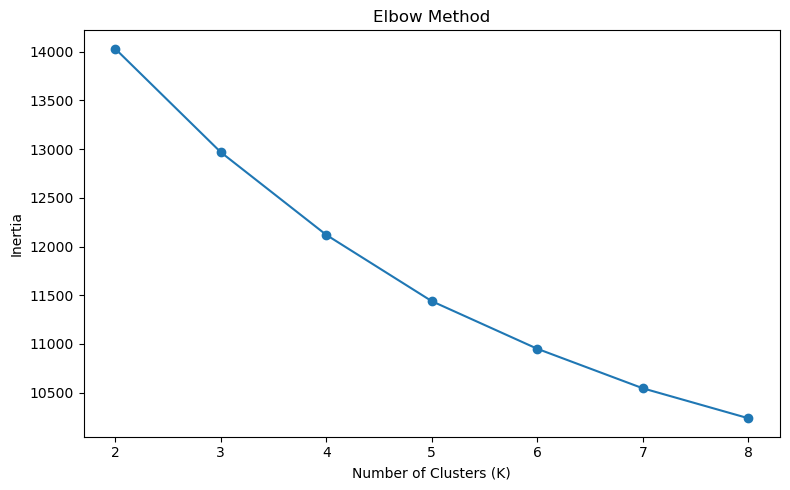

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("../Output-charts/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

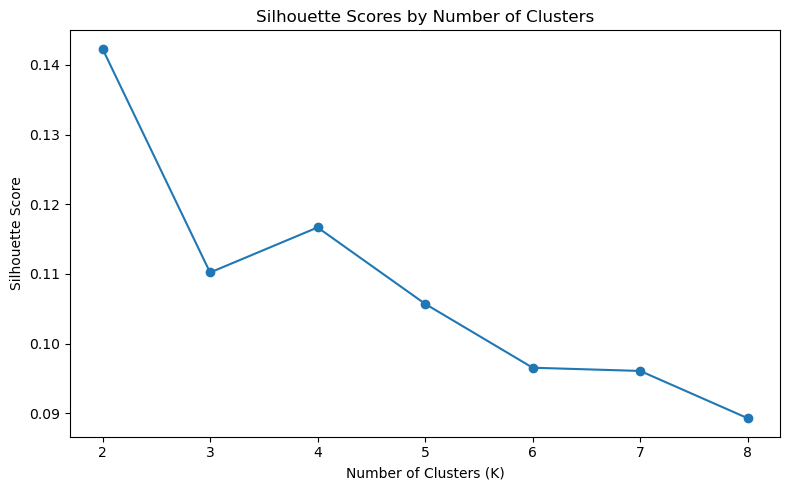

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Scores by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("../Output-charts/silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
df_enriched.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,dob_parsed,age,client_ref,sold_property_count,avg_sale_price,total_sale_price,avg_floor_area_sqft,latest_transaction_date,apartment_count,office_count
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,1968-05-11,58,C0001,4,311691.180000,1246764.72,983.885000,2025-01-12,4,0
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,1962-11-26,63,C0002,5,368219.186000,1841095.93,1187.942000,2025-01-12,5,0
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,...,1959-04-07,67,C0003,5,332291.518000,1661457.59,1058.110000,2025-01-10,5,0
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,...,1959-11-25,66,C0004,6,268043.918333,1608263.51,937.103333,2025-01-08,6,0
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,...,1976-02-28,50,C0005,13,281029.644615,3653385.38,927.296154,2025-01-05,13,0


In [30]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_enriched["cluster"] = final_kmeans.fit_predict(features_encoded)

In [31]:
df_enriched["cluster"].value_counts()

cluster
3    750
0    622
2    541
1     87
Name: count, dtype: int64

In [32]:
df_enriched["cluster"].value_counts(normalize=True) * 100

cluster
3    37.50
0    31.10
2    27.05
1     4.35
Name: proportion, dtype: float64

In [33]:
df_enriched[["client_id", "client_type", "acquisition_purpose", "age", "sold_property_count", "avg_sale_price", "cluster"]].head(10)

,client_id,client_type,acquisition_purpose,age,sold_property_count,avg_sale_price,cluster
0,C0001,Individual,Home,58,4,311691.180000,3
1,C0002,Individual,Home,63,5,368219.186000,2
2,C0003,Individual,Home,67,5,332291.518000,1
3,C0004,Individual,Home,66,6,268043.918333,1
4,C0005,Company,Investment,50,13,281029.644615,1
5,C0006,Individual,Home,69,5,302826.212000,1
6,C0007,Individual,Investment,79,11,295558.893636,1
7,C0008,Individual,Home,56,5,295346.082000,3
8,C0009,Individual,Investment,50,5,364166.470000,1
9,C0010,Individual,Investment,60,5,346486.800000,1


In [34]:
df_enriched[["cluster"]].isna().sum()

cluster    0
dtype: int64

In [35]:
df_enriched.groupby("cluster")[["age", "satisfaction_score", "sold_property_count", "avg_sale_price", "avg_floor_area_sqft"]].mean()

,age,satisfaction_score,sold_property_count,avg_sale_price,avg_floor_area_sqft
cluster,,,,,
0,55.263666,3.075563,3.424437,427988.467297,1402.264561
1,66.425287,3.620690,6.344828,334367.821999,1111.138153
2,54.942699,1.452865,3.571165,311577.799711,1034.064972
3,55.784000,4.058667,3.588000,307089.993229,1022.203480


In [36]:
df_enriched.to_csv("../Data-processed/clients_clustered.csv", index=False)

In [37]:
cluster_profile_numeric = df_enriched.groupby("cluster")[["age", "satisfaction_score", "sold_property_count", "avg_sale_price", "avg_floor_area_sqft"]].mean()
cluster_profile_numeric.to_csv("../Data-processed/cluster_profile_numeric.csv")

In [38]:
cluster_profile_numeric = (
    df_enriched.groupby("cluster")[[
        "age",
        "satisfaction_score",
        "sold_property_count",
        "avg_sale_price",
        "avg_floor_area_sqft"
    ]]
    .mean()
    .round(2)
)

cluster_profile_numeric

,age,satisfaction_score,sold_property_count,avg_sale_price,avg_floor_area_sqft
cluster,,,,,
0,55.26,3.08,3.42,427988.47,1402.26
1,66.43,3.62,6.34,334367.82,1111.14
2,54.94,1.45,3.57,311577.80,1034.06
3,55.78,4.06,3.59,307089.99,1022.20


In [39]:
cluster_profile_numeric.to_csv("../Data-processed/cluster_profile_numeric.csv")

In [40]:
cluster_profile_client_type = (
    pd.crosstab(
        df_enriched["cluster"],
        df_enriched["client_type"],
        normalize="index"
    ) * 100
).round(2)

cluster_profile_client_type

client_type,Company,Individual
cluster,,
0,5.95,94.05
1,3.45,96.55
2,5.36,94.64
3,4.53,95.47


In [41]:
cluster_profile_purpose = (
    pd.crosstab(
        df_enriched["cluster"],
        df_enriched["acquisition_purpose"],
        normalize="index"
    ) * 100
).round(2)

cluster_profile_purpose

acquisition_purpose,Home,Investment
cluster,,
0,71.06,28.94
1,70.11,29.89
2,67.47,32.53
3,68.93,31.07


In [42]:
cluster_profile_loan = (
    pd.crosstab(
        df_enriched["cluster"],
        df_enriched["loan_applied"],
        normalize="index"
    ) * 100
).round(2)

cluster_profile_loan

loan_applied,No,Yes
cluster,,
0,62.54,37.46
1,63.22,36.78
2,63.96,36.04
3,63.20,36.80


In [43]:
cluster_profile_referral = (
    pd.crosstab(
        df_enriched["cluster"],
        df_enriched["referral_channel"],
        normalize="index"
    ) * 100
).round(2)

cluster_profile_referral

referral_channel,Agency,Client,Website
cluster,,,
0,34.89,8.68,56.43
1,26.44,8.05,65.52
2,34.57,10.72,54.71
3,37.07,9.73,53.20


In [44]:
cluster_profile_gender = (
    pd.crosstab(
        df_enriched["cluster"],
        df_enriched["gender"],
        normalize="index"
    ) * 100
).round(2)

cluster_profile_gender

gender,F,M
cluster,,
0,47.75,52.25
1,42.53,57.47
2,48.80,51.20
3,52.00,48.00


In [45]:
cluster_profile_country = (
    pd.crosstab(
        df_enriched["cluster"],
        df_enriched["country"],
        normalize="index"
    ) * 100
).round(2)

cluster_profile_country

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
cluster,,,,,,,,,,
0,1.45,1.29,4.02,1.29,2.73,2.89,1.93,1.77,5.47,77.17
1,0.00,1.15,1.15,0.00,1.15,1.15,0.00,1.15,3.45,90.80
2,2.40,2.59,4.44,0.92,2.77,2.77,1.85,2.03,4.99,75.23
3,2.27,2.67,4.67,0.27,2.67,2.93,2.40,1.73,4.13,76.27


In [46]:
cluster_profile_client_type.to_csv("../Data-processed/cluster_profile_client_type.csv")
cluster_profile_purpose.to_csv("../Data-processed/cluster_profile_purpose.csv")
cluster_profile_loan.to_csv("../Data-processed/cluster_profile_loan.csv")
cluster_profile_referral.to_csv("../Data-processed/cluster_profile_referral.csv")
cluster_profile_gender.to_csv("../Data-processed/cluster_profile_gender.csv")
cluster_profile_country.to_csv("../Data-processed/cluster_profile_country.csv")

In [47]:
for cluster_id in sorted(df_enriched["cluster"].unique()):
    print(f"\n--- Cluster {cluster_id} top regions ---")
    print(
        (df_enriched[df_enriched["cluster"] == cluster_id]["region"]
         .value_counts(normalize=True)
         .head(3) * 100)
        .round(2)
    )


--- Cluster 0 top regions ---
region
California    32.15
Nevada         7.56
Arizona        6.11
Name: proportion, dtype: float64

--- Cluster 1 top regions ---
region
California    55.17
Nevada        10.34
Oregon         8.05
Name: proportion, dtype: float64

--- Cluster 2 top regions ---
region
California    31.61
Nevada         6.84
Colorado       6.47
Name: proportion, dtype: float64

--- Cluster 3 top regions ---
region
California    28.53
Colorado       7.47
Nevada         6.67
Name: proportion, dtype: float64


In [48]:
cluster_name_map = {
    0: "Premium Large-Property Buyers",
    1: "Older Multi-Property Buyers",
    2: "Dissatisfied Mid-Value Buyers",
    3: "Satisfied Value-Oriented Buyers"
}

df_enriched["cluster_name"] = df_enriched["cluster"].map(cluster_name_map)

In [49]:
df_enriched.to_csv("../Data-processed/clients_clustered_named.csv", index=False)

In [50]:
final_cluster_summary = (
    df_enriched.groupby(["cluster", "cluster_name"])
    .agg(
        client_count=("client_id", "count"),
        avg_age=("age", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_sold_property_count=("sold_property_count", "mean"),
        avg_sale_price=("avg_sale_price", "mean"),
        avg_floor_area_sqft=("avg_floor_area_sqft", "mean")
    )
    .reset_index()
)

final_cluster_summary["cluster_pct"] = (
    final_cluster_summary["client_count"] / final_cluster_summary["client_count"].sum() * 100
)

final_cluster_summary = final_cluster_summary.round({
    "avg_age": 2,
    "avg_satisfaction": 2,
    "avg_sold_property_count": 2,
    "avg_sale_price": 2,
    "avg_floor_area_sqft": 2,
    "cluster_pct": 2
})

final_cluster_summary

,cluster,cluster_name,client_count,avg_age,avg_satisfaction,avg_sold_property_count,avg_sale_price,avg_floor_area_sqft,cluster_pct
0,0,Premium Large-Property Buyers,622,55.26,3.08,3.42,427988.47,1402.26,31.10
1,1,Older Multi-Property Buyers,87,66.43,3.62,6.34,334367.82,1111.14,4.35
2,2,Dissatisfied Mid-Value Buyers,541,54.94,1.45,3.57,311577.80,1034.06,27.05
3,3,Satisfied Value-Oriented Buyers,750,55.78,4.06,3.59,307089.99,1022.20,37.50


In [51]:
final_cluster_summary.to_csv("../Data-processed/final_cluster_summary.csv", index=False)

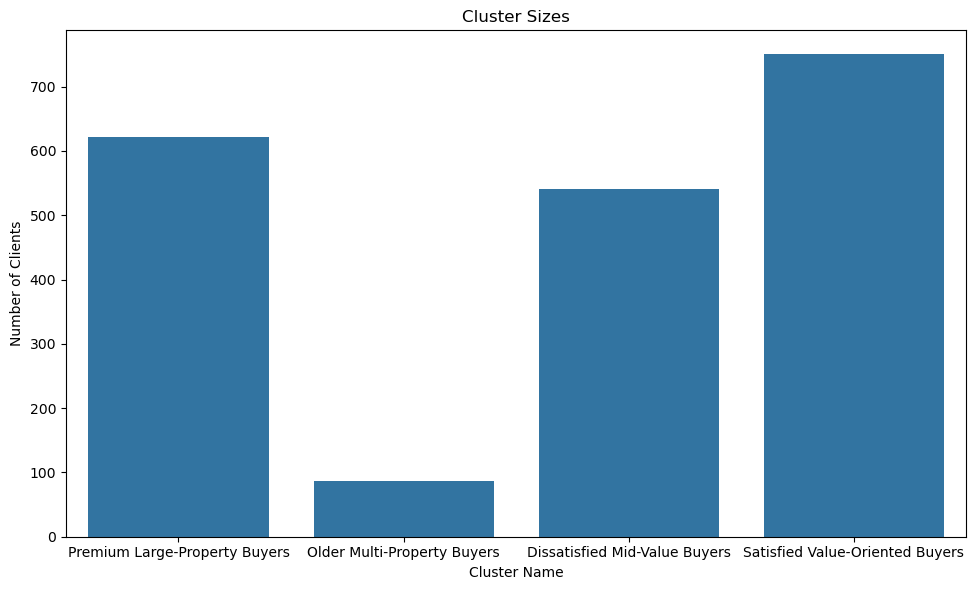

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final_cluster_summary, x="cluster_name", y="client_count")
plt.title("Cluster Sizes")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0final_cluster_summary = final_cluster_summary.sort_values("client_count", ascending=False)
final_cluster_summary, ha="center")
plt.tight_layout()
plt.savefig("../Output-charts/cluster_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
final_cluster_summary = final_cluster_summary.sort_values("client_count", ascending=False)
final_cluster_summary

,cluster,cluster_name,client_count,avg_age,avg_satisfaction,avg_sold_property_count,avg_sale_price,avg_floor_area_sqft,cluster_pct
3,3,Satisfied Value-Oriented Buyers,750,55.78,4.06,3.59,307089.99,1022.20,37.50
0,0,Premium Large-Property Buyers,622,55.26,3.08,3.42,427988.47,1402.26,31.10
2,2,Dissatisfied Mid-Value Buyers,541,54.94,1.45,3.57,311577.80,1034.06,27.05
1,1,Older Multi-Property Buyers,87,66.43,3.62,6.34,334367.82,1111.14,4.35


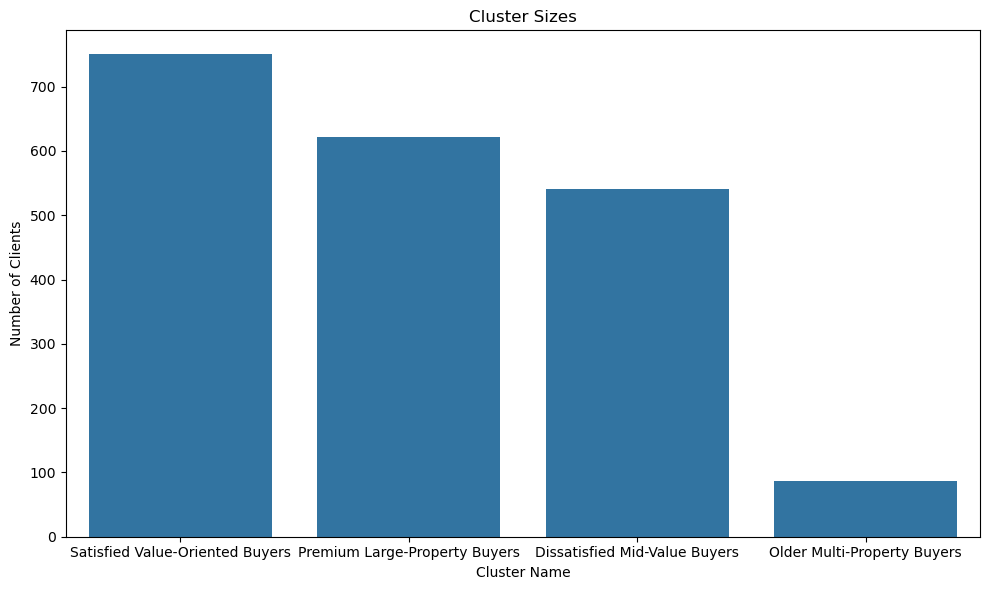

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final_cluster_summary, x="cluster_name", y="client_count")
plt.title("Cluster Sizes")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.savefig("../Output-charts/cluster_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
final_cluster_summary.to_csv("../Data-processed/final_cluster_summary.csv", index=False)

In [62]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [63]:
dendrogram_sample = features_encoded.sample(n=300, random_state=42)

In [64]:
linkage_matrix = linkage(dendrogram_sample, method="ward")

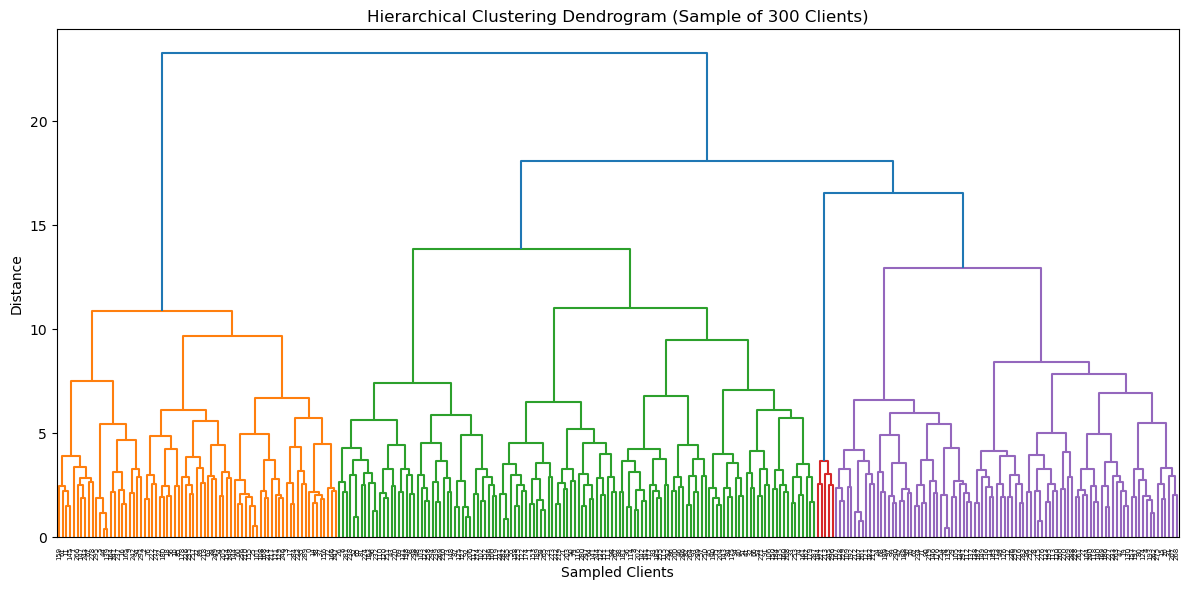

In [66]:
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram (Sample of 300 Clients)")
plt.xlabel("Sampled Clients")
plt.ylabel("Distance")
plt.xticks(rotation=90, ha="center")
plt.tight_layout()
plt.savefig("../Output-charts/hierarchical_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [67]:
hierarchical_model = AgglomerativeClustering(n_clusters=4, linkage="ward")
df_enriched["hierarchical_cluster"] = hierarchical_model.fit_predict(features_encoded)

In [68]:
df_enriched["hierarchical_cluster"].value_counts()

hierarchical_cluster
3    711
0    611
1    607
2     71
Name: count, dtype: int64

In [69]:
df_enriched["hierarchical_cluster"].value_counts(normalize=True) * 100

hierarchical_cluster
3    35.55
0    30.55
1    30.35
2     3.55
Name: proportion, dtype: float64

In [70]:
hierarchical_silhouette = silhouette_score(features_encoded, df_enriched["hierarchical_cluster"])
hierarchical_silhouette

0.08390084754771072

In [71]:
pd.crosstab(df_enriched["cluster"], df_enriched["hierarchical_cluster"])

hierarchical_cluster,0,1,2,3
cluster,,,,
0,481,45,1,95
1,9,10,64,4
2,11,37,0,493
3,110,515,6,119


In [72]:
df_enriched.to_csv("../Data-processed/clients_clustered_validated.csv", index=False)

In [1]:
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt

st.set_page_config(page_title="Buyer Segmentation Dashboard", layout="wide")

# -----------------------------
# Data Loading
# -----------------------------
@st.cache_data

def load_data():
    df = pd.read_csv("../Data-processed/clients_clustered_named.csv")
    return df


df = load_data()

# -----------------------------
# Title and Intro
# -----------------------------
st.title("Buyer Segmentation and Investment Profiling Dashboard")
st.markdown(
    "This dashboard presents buyer segments created using machine learning-based clustering. "
    "Use the filters on the left to explore differences in buyer behavior, geography, financing, and property characteristics."
)

# -----------------------------
# Sidebar Filters
# -----------------------------
st.sidebar.header("Filters")

country_options = ["All"] + sorted(df["country"].dropna().unique().tolist())
region_options = ["All"] + sorted(df["region"].dropna().unique().tolist())
purpose_options = ["All"] + sorted(df["acquisition_purpose"].dropna().unique().tolist())
client_type_options = ["All"] + sorted(df["client_type"].dropna().unique().tolist())

selected_country = st.sidebar.selectbox("Country", country_options)
selected_region = st.sidebar.selectbox("Region", region_options)
selected_purpose = st.sidebar.selectbox("Acquisition Purpose", purpose_options)
selected_client_type = st.sidebar.selectbox("Client Type", client_type_options)

filtered_df = df.copy()

if selected_country != "All":
    filtered_df = filtered_df[filtered_df["country"] == selected_country]

if selected_region != "All":
    filtered_df = filtered_df[filtered_df["region"] == selected_region]

if selected_purpose != "All":
    filtered_df = filtered_df[filtered_df["acquisition_purpose"] == selected_purpose]

if selected_client_type != "All":
    filtered_df = filtered_df[filtered_df["client_type"] == selected_client_type]

# -----------------------------
# Safety Check
# -----------------------------
if filtered_df.empty:
    st.warning("No records match the selected filters. Please adjust the filter settings.")
    st.stop()

# -----------------------------
# Key Metrics
# -----------------------------
st.subheader("Dashboard Summary")
col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Clients", len(filtered_df))
col2.metric("Clusters Present", filtered_df["cluster_name"].nunique())
col3.metric("Average Age", round(filtered_df["age"].mean(), 2))
col4.metric("Average Satisfaction", round(filtered_df["satisfaction_score"].mean(), 2))

# -----------------------------
# Buyer Segmentation Overview
# -----------------------------
st.header("1. Buyer Segmentation Overview")

cluster_counts = filtered_df["cluster_name"].value_counts().reset_index()
cluster_counts.columns = ["cluster_name", "client_count"]

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(cluster_counts["cluster_name"], cluster_counts["client_count"])
ax1.set_title("Cluster Distribution")
ax1.set_xlabel("Cluster Name")
ax1.set_ylabel("Number of Clients")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
st.pyplot(fig1)

st.dataframe(cluster_counts, use_container_width=True)

# -----------------------------
# Investor Behavior Dashboard
# -----------------------------
st.header("2. Investor Behavior Dashboard")

col_a, col_b = st.columns(2)

with col_a:
    purpose_by_cluster = pd.crosstab(filtered_df["cluster_name"], filtered_df["acquisition_purpose"])
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    purpose_by_cluster.plot(kind="bar", ax=ax2)
    ax2.set_title("Acquisition Purpose by Cluster")
    ax2.set_xlabel("Cluster Name")
    ax2.set_ylabel("Count")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    st.pyplot(fig2)

with col_b:
    loan_by_cluster = pd.crosstab(filtered_df["cluster_name"], filtered_df["loan_applied"])
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    loan_by_cluster.plot(kind="bar", ax=ax3)
    ax3.set_title("Loan Status by Cluster")
    ax3.set_xlabel("Cluster Name")
    ax3.set_ylabel("Count")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    st.pyplot(fig3)

satisfaction_by_cluster = filtered_df.groupby("cluster_name")["satisfaction_score"].mean().sort_values(ascending=False)
fig4, ax4 = plt.subplots(figsize=(10, 5))
ax4.bar(satisfaction_by_cluster.index, satisfaction_by_cluster.values)
ax4.set_title("Average Satisfaction Score by Cluster")
ax4.set_xlabel("Cluster Name")
ax4.set_ylabel("Average Satisfaction Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
st.pyplot(fig4)

# -----------------------------
# Geographic Buyer Analysis
# -----------------------------
st.header("3. Geographic Buyer Analysis")

col_c, col_d = st.columns(2)

with col_c:
    country_counts = filtered_df["country"].value_counts().head(10)
    fig5, ax5 = plt.subplots(figsize=(8, 5))
    ax5.bar(country_counts.index, country_counts.values)
    ax5.set_title("Top Countries in Filtered Dataset")
    ax5.set_xlabel("Country")
    ax5.set_ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    st.pyplot(fig5)

with col_d:
    region_counts = filtered_df["region"].value_counts().head(10)
    fig6, ax6 = plt.subplots(figsize=(8, 5))
    ax6.bar(region_counts.index, region_counts.values)
    ax6.set_title("Top Regions in Filtered Dataset")
    ax6.set_xlabel("Region")
    ax6.set_ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    st.pyplot(fig6)

geo_cluster = pd.crosstab(filtered_df["cluster_name"], filtered_df["country"])
st.subheader("Country Distribution by Cluster")
st.dataframe(geo_cluster, use_container_width=True)

# -----------------------------
# Segment Insights Panel
# -----------------------------
st.header("4. Segment Insights Panel")

segment_summary = (
    filtered_df.groupby("cluster_name")
    .agg(
        client_count=("client_id", "count"),
        avg_age=("age", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_sold_property_count=("sold_property_count", "mean"),
        avg_sale_price=("avg_sale_price", "mean"),
        avg_floor_area_sqft=("avg_floor_area_sqft", "mean")
    )
    .round(2)
    .reset_index()
)

st.dataframe(segment_summary, use_container_width=True)

cluster_descriptions = {
    "Premium Large-Property Buyers": "Higher-value buyers associated with larger floor-area properties and stronger premium-market positioning.",
    "Older Multi-Property Buyers": "A small but distinct older segment with the highest transaction intensity and repeat or portfolio-style behavior.",
    "Dissatisfied Mid-Value Buyers": "Mid-value buyers whose most distinctive feature is weak satisfaction, suggesting service or journey friction.",
    "Satisfied Value-Oriented Buyers": "The largest cluster, characterized by lower-value properties but stronger satisfaction and stable mainstream behavior."
}

selected_cluster_name = st.selectbox(
    "Select a cluster to view its business interpretation",
    sorted(filtered_df["cluster_name"].unique().tolist())
)

st.markdown(f"**Cluster Description:** {cluster_descriptions.get(selected_cluster_name, 'Description not available.')}" )

selected_cluster_df = filtered_df[filtered_df["cluster_name"] == selected_cluster_name]

col_e, col_f = st.columns(2)
with col_e:
    st.write("**Top Countries in Selected Cluster**")
    st.dataframe(
        selected_cluster_df["country"].value_counts(normalize=True).mul(100).round(2).head(10).rename("percentage").reset_index(),
        use_container_width=True,
    )

with col_f:
    st.write("**Top Regions in Selected Cluster**")
    st.dataframe(
        selected_cluster_df["region"].value_counts(normalize=True).mul(100).round(2).head(10).rename("percentage").reset_index(),
        use_container_width=True,
    )

# -----------------------------
# Data Preview
# -----------------------------
st.header("5. Filtered Data Preview")
st.dataframe(filtered_df.head(50), use_container_width=True)


2026-04-09 14:15:43.263 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 14:15:43.264 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-09 14:15:43.265 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-09 14:15:43.266 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 14:15:43.791 
  command:

    streamlit run C:\Users\15130\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-09 14:15:43.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 14:15:43.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running 

DeltaGenerator()